<a href="https://colab.research.google.com/github/eminetrkmn/rag-pdf-assistant/blob/main/Haystack_ile_AI_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:

!pip install haystack-ai
!pip install "sentence-transformers>=3.0.0" "huggingface_hub>=0.23.0"
!pip install pypdf

In [18]:
from haystack import Pipeline
from haystack.document_stores.in_memory import InMemoryDocumentStore
from haystack.components.converters import PyPDFToDocument
from haystack.components.preprocessors import DocumentCleaner
from haystack.components.preprocessors import DocumentSplitter
from haystack.components.writers import DocumentWriter
from haystack.components.embedders import  OpenAITextEmbedder, OpenAIDocumentEmbedder
from google.colab import userdata
import os
os.environ["OPENAI_API_KEY"]=userdata.get('OPENAI_API_KEY')

document_store = InMemoryDocumentStore()
document_embedder=OpenAIDocumentEmbedder()

pipeline = Pipeline()
pipeline.add_component("converter", PyPDFToDocument())
pipeline.add_component("cleaner", DocumentCleaner())
pipeline.add_component("splitter", DocumentSplitter(split_by="sentence", split_length=5))
pipeline.add_component("embedder", instance=document_embedder)
pipeline.add_component("writer", DocumentWriter(document_store=document_store))
pipeline.connect("converter", "cleaner")
pipeline.connect("cleaner", "splitter")
pipeline.connect("splitter", "embedder")
pipeline.connect("embedder", "writer")

file_names=["/content/emine_turkmen_cv.pdf"]

pipeline.run({"converter": {"sources": file_names}})

Calculating embeddings: 1it [00:00,  1.01it/s]


{'embedder': {'meta': {'model': 'text-embedding-ada-002-v2',
   'usage': {'prompt_tokens': 2202, 'total_tokens': 2202}}},
 'writer': {'documents_written': 6}}

In [20]:
from haystack.components.retrievers.in_memory import InMemoryEmbeddingRetriever
from haystack.components.builders import PromptBuilder
from haystack.components.generators.chat import OpenAIChatGenerator
from haystack.components.embedders import OpenAITextEmbedder

text_embedder = OpenAITextEmbedder()
retriever = InMemoryEmbeddingRetriever(document_store)

template = """Given these documents, answer the question.
              Documents:
              {% for doc in documents %}
                  {{ doc.content }}
              {% endfor %}
              Question: {{query}}
              Answer:"""

prompt_builder=PromptBuilder(template=template)

llm = OpenAIChatGenerator()

In [21]:
rag_pipeline = Pipeline()
rag_pipeline.add_component("text_embedder", text_embedder)
rag_pipeline.add_component("retriever", retriever)
rag_pipeline.add_component("prompt_builder", prompt_builder)
rag_pipeline.add_component("llm", llm)

rag_pipeline.connect("text_embedder.embedding","retriever.query_embedding")
rag_pipeline.connect("retriever","prompt_builder")
rag_pipeline.connect("prompt_builder","llm")

🚅 Components
  - text_embedder: OpenAITextEmbedder
  - retriever: InMemoryEmbeddingRetriever
  - prompt_builder: PromptBuilder
  - llm: OpenAIChatGenerator
🛤️ Connections
  - text_embedder.embedding -> retriever.query_embedding (list[float])
  - retriever.documents -> prompt_builder.documents (list[Document])
  - prompt_builder.prompt -> llm.messages (str)

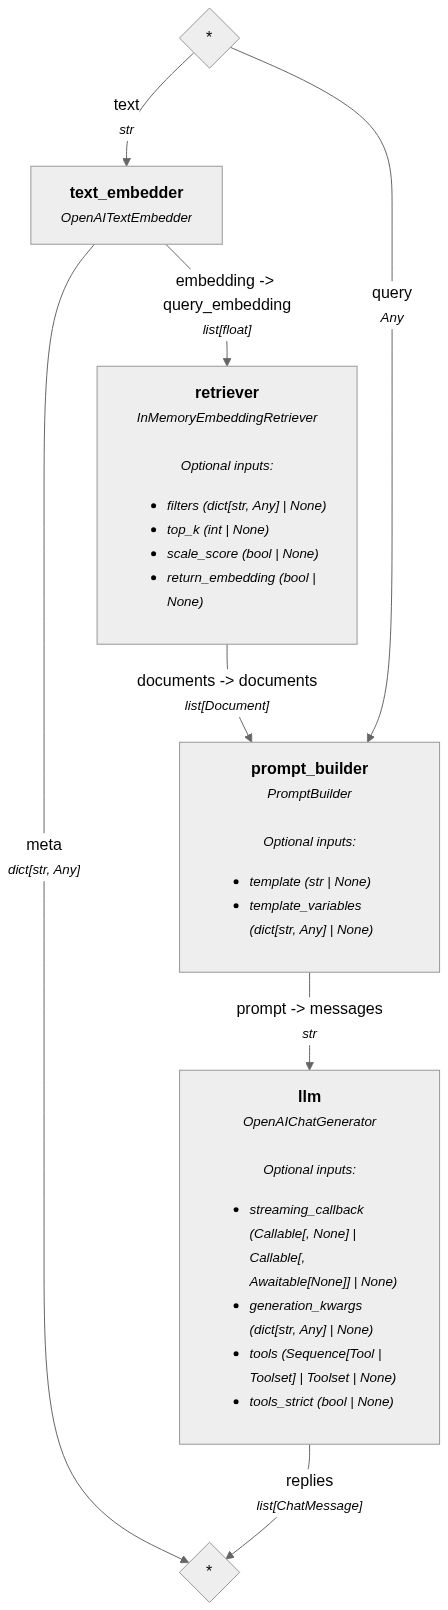

In [22]:
rag_pipeline.show()

In [23]:
query = "Hangi programlama dillerini biliyor?"

result = rag_pipeline.run({
    "text_embedder": {"text": query},
    "prompt_builder": {"query": query}
})

print(result["llm"]["replies"][0].text)

C, Java, C++, JavaScript ve Python.


In [25]:
query = "Hangi üniversitede ve hangi bölümde okuyor?"
result = rag_pipeline.run({
    "text_embedder": {"text": query},
    "prompt_builder": {"query": query}
})

print(result["llm"]["replies"][0].text)

Gebze Teknik Üniversitesi, Bilgisayar Mühendisliği bölümünde okuyorum.


In [26]:
query = "Tetra HGS'deki stajında neler yaptı?"

result = rag_pipeline.run({
    "text_embedder": {"text": query},
    "prompt_builder": {"query": query}
})

print(result["llm"]["replies"][0].text)

Tetra HGS’daki Yazılım Geliştirme Stajı sırasında yaptığı işler (Temmuz–Ağustos 2026):

- Abonelik şirketi için müşteri kaybı (churn) tahmini yapan uçtan uca makine öğrenmesi sistemi geliştirdi.  
  - Ham veriyi temizledi; Label Encoding / One‑Hot Encoding ile sayısallaştırma yaptı.  
  - Random Forest sınıflandırıcıyla hiperparametre optimizasyonu uyguladı; recall değerini 0.51’den 0.80’e yükseltti.

- Eğitilen modeli üretime taşıdı: asenkron tahmin servisini FastAPI ile sundu.  
- Spring Boot tabanlı REST API, DTO katmanı ve veritabanı entegrasyonunu geliştirdi.  
- Servisleri Docker ile konteynerleştirdi.  
- React ile interaktif bir panel geliştirip müşteri risk skorlarının görselleştirilmesini ve backend’e bağlanmasını sağladı.


In [28]:
query = "Bu kişiyi bir yapay zeka stajı için neden işe almalıyız? Deneyimlerine göre özetle."

result = rag_pipeline.run({
    "text_embedder": {"text": query},
    "prompt_builder": {"query": query}
})

print(result["llm"]["replies"][0].text)

Kısa cevap: Bu aday, üretken yapay zekâ ve makine öğrenimi projelerini uçtan uca tasarlayıp canlıya alma deneyimi, güçlü programlama altyapısı ve liderlik/öğretmenlik tecrübesi sayesinde bir yapay zeka stajı için çok uygun.

Öne çıkan nedenler:
- Teknik yetkinlikler: Python, C/C++, Java, JavaScript; ML/AI ekosistemi (Scikit‑learn, Pandas, Sentence‑Transformers) ve LLM/RAG araçları (Groq LLM, ChromaDB, embeddingler).
- Uçtan uca proje deneyimi: RAG+LLM tabanlı “DersNotu Çalışma Asistanı” (embedding, ChromaDB, FastAPI, React) ile belge indeksleme, kaynak gösterimli cevap üretme ve quiz modülü; FastAPI/Spring Boot ve Docker ile servisleştirme deneyimi.
- Model ve veri mühendisliği pratiği: Gerçek veri ön işleme, özellik mühendisliği (batarya sağlık metriği türetme), sensör verisi temizleme, ML model optimizasyonu (churn modelinde recall’u 0.51 → 0.80’a yükseltme).
- Üretime alma ve entegrasyon: REST API tasarımı, Spring Boot ile backend, asenkron tahmin servisi, Docker konteynerleri ve Re